### Load Data

Loading the `alzheimers_final_ml_dataset_with_trajectory (1).csv` dataset into a pandas DataFrame.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/alzheimers_final_ml_dataset_with_trajectory (1).csv')
display(df.head())

,Sample,BIN1,CLU,PICALM,ABCA7,CD33,APOE_GENOTYPE,APOE_E4_DOSAGE,APOE_E2_DOSAGE,APOE_E4_CARRIER,BASELINE_DX,BASELINE_DX_ENC,DIAGNOSIS_WORST,AD_STATUS,EARLY_TRAJECTORY,EARLY_TRAJECTORY_ENC,n_visits
0,036_S_6231,0.0,0.0,1.0,0.0,0.0,3/4,1.0,0.0,1.0,Dementia,2.0,Dementia,1.0,Stable_Dementia,4.0,3.0
1,006_S_6277,0.0,1.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,CN,0.0,CN,0.0,Stable_CN,0.0,4.0
2,129_S_6146,1.0,2.0,0.0,1.0,1.0,3/3,0.0,0.0,0.0,CN,0.0,CN,0.0,Stable_CN,0.0,6.0
3,033_S_6352,1.0,1.0,1.0,0.0,0.0,3/4,1.0,0.0,1.0,CN,0.0,MCI,0.0,Stable_CN,0.0,7.0
4,027_S_6183,1.0,0.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,CN,0.0,CN,0.0,Stable_CN,0.0,6.0


In [ ]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
display(df.dtypes)

# Missing values
print("\nMissing Values:")
display(df.isnull().sum())

Shape: (655, 17)

Columns:
['Sample', 'BIN1', 'CLU', 'PICALM', 'ABCA7', 'CD33', 'APOE_GENOTYPE', 'APOE_E4_DOSAGE', 'APOE_E2_DOSAGE', 'APOE_E4_CARRIER', 'BASELINE_DX', 'BASELINE_DX_ENC', 'DIAGNOSIS_WORST', 'AD_STATUS', 'EARLY_TRAJECTORY', 'EARLY_TRAJECTORY_ENC', 'n_visits']

Data Types:


,0
Sample,object
BIN1,float64
CLU,float64
PICALM,float64
ABCA7,float64
CD33,float64
APOE_GENOTYPE,object
APOE_E4_DOSAGE,float64
APOE_E2_DOSAGE,float64
APOE_E4_CARRIER,float64



Missing Values:


,0
Sample,0
BIN1,3
CLU,0
PICALM,0
ABCA7,0
CD33,0
APOE_GENOTYPE,5
APOE_E4_DOSAGE,5
APOE_E2_DOSAGE,5
APOE_E4_CARRIER,5


In [ ]:
print(df['BASELINE_DX_ENC'].value_counts())

print("\nPercentage Distribution:")
display(df['BASELINE_DX_ENC'].value_counts(normalize=True) * 100)

BASELINE_DX_ENC
0.0    354
1.0    225
2.0     70
Name: count, dtype: int64

Percentage Distribution:


,proportion
BASELINE_DX_ENC,
0.0,54.545455
1.0,34.668721
2.0,10.785824


In [ ]:
df = df.dropna()

print(df.shape)

(646, 17)


In [ ]:
features = [
    'BIN1',
    'CLU',
    'PICALM',
    'ABCA7',
    'CD33',
    'APOE_GENOTYPE',
    'APOE_E4_DOSAGE',
    'APOE_E2_DOSAGE',
    'APOE_E4_CARRIER'
]

X = df[features]

y = df['BASELINE_DX_ENC']

In [ ]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (646, 9)
y Shape: (646,)

Target Distribution:
BASELINE_DX_ENC
0.0    352
1.0    225
2.0     69
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 516
Testing samples : 130


In [ ]:
print("Training Distribution")
print(y_train.value_counts())

print("\nTesting Distribution")
print(y_test.value_counts())

Training Distribution
BASELINE_DX_ENC
0.0    281
1.0    180
2.0     55
Name: count, dtype: int64

Testing Distribution
BASELINE_DX_ENC
0.0    71
1.0    45
2.0    14
Name: count, dtype: int64


In [ ]:
X_train = pd.get_dummies(X_train, columns=['APOE_GENOTYPE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['APOE_GENOTYPE'], drop_first=True)

# Ensure both train and test have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Fold Accuracies:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Fold Accuracies: [0.41346154 0.42718447 0.44660194 0.4368932  0.47572816]
Mean CV Accuracy: 0.43997386109036596
Std Dev: 0.020967896111703993


In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:
print(X_train.dtypes)

BIN1                 float64
CLU                  float64
PICALM               float64
ABCA7                float64
CD33                 float64
APOE_E4_DOSAGE       float64
APOE_E2_DOSAGE       float64
APOE_E4_CARRIER      float64
APOE_GENOTYPE_2/3       bool
APOE_GENOTYPE_2/4       bool
APOE_GENOTYPE_3/3       bool
APOE_GENOTYPE_3/4       bool
APOE_GENOTYPE_4/4       bool
dtype: object


In [ ]:
print(X_train.columns)
print(X_train.dtypes)

Index(['BIN1', 'CLU', 'PICALM', 'ABCA7', 'CD33', 'APOE_E4_DOSAGE',
       'APOE_E2_DOSAGE', 'APOE_E4_CARRIER', 'APOE_GENOTYPE_2/3',
       'APOE_GENOTYPE_2/4', 'APOE_GENOTYPE_3/3', 'APOE_GENOTYPE_3/4',
       'APOE_GENOTYPE_4/4'],
      dtype='object')
BIN1                 float64
CLU                  float64
PICALM               float64
ABCA7                float64
CD33                 float64
APOE_E4_DOSAGE       float64
APOE_E2_DOSAGE       float64
APOE_E4_CARRIER      float64
APOE_GENOTYPE_2/3       bool
APOE_GENOTYPE_2/4       bool
APOE_GENOTYPE_3/3       bool
APOE_GENOTYPE_3/4       bool
APOE_GENOTYPE_4/4       bool
dtype: object


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the model
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.46153846153846156

Confusion Matrix
[[45 22  4]
 [29 12  4]
 [ 7  4  3]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.56      0.63      0.59        71
         1.0       0.32      0.27      0.29        45
         2.0       0.27      0.21      0.24        14

    accuracy                           0.46       130
   macro avg       0.38      0.37      0.37       130
weighted avg       0.44      0.46      0.45       130



In [ ]:
import pandas as pd

pd.crosstab(df['APOE_GENOTYPE'], df['BASELINE_DX'])

BASELINE_DX,CN,Dementia,MCI
APOE_GENOTYPE,,,
2/2,0,0,1
2/3,39,2,12
2/4,8,3,4
3/3,191,22,117
3/4,101,25,71
4/4,13,17,20


In [ ]:
pd.crosstab(df['BASELINE_DX'], df['AD_STATUS'])

AD_STATUS,0.0,1.0
BASELINE_DX,,
CN,349,3
Dementia,0,69
MCI,179,46


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Clean the data
# Dropping columns that are unique identifiers or redundant text-based labels
# that might cause 'data leakage' (where the answer is essentially given to the model)
columns_to_drop = ['Sample', 'BASELINE_DX', 'DIAGNOSIS_WORST', 'EARLY_TRAJECTORY']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 2. Encode categorical data
# APOE_GENOTYPE contains strings like '3/3' or '3/4', so we convert these to dummy variables
df_clean = pd.get_dummies(df_clean, columns=['APOE_GENOTYPE'], drop_first=True)

# 3. Define Features (X) and Target (y)
X = df_clean.drop('AD_STATUS', axis=1)
y = df_clean['AD_STATUS']

# 4. Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Evaluate
y_pred = rf_model.predict(X_test)

print("Model Performance:")
print(classification_report(y_test, y_pred))

Model Performance:
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       108
         1.0       0.89      0.73      0.80        22

    accuracy                           0.94       130
   macro avg       0.92      0.85      0.88       130
weighted avg       0.94      0.94      0.94       130



In [ ]:
print(X.columns)

Index(['BIN1', 'CLU', 'PICALM', 'ABCA7', 'CD33', 'APOE_E4_DOSAGE',
       'APOE_E2_DOSAGE', 'APOE_E4_CARRIER', 'BASELINE_DX_ENC',
       'EARLY_TRAJECTORY_ENC', 'n_visits', 'APOE_GENOTYPE_2/3',
       'APOE_GENOTYPE_2/4', 'APOE_GENOTYPE_3/3', 'APOE_GENOTYPE_3/4',
       'APOE_GENOTYPE_4/4'],
      dtype='object')


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Load data
df = pd.read_csv('/content/alzheimers_final_ml_dataset_with_trajectory (1).csv')

# Drop rows with NaN in 'AD_STATUS' before defining X and y
df.dropna(subset=['AD_STATUS'], inplace=True)

# 2. Define the 'Leakage-Free' feature set
# We drop everything related to the diagnosis and future trajectory
columns_to_drop = [
    'Sample',
    'BASELINE_DX',
    'BASELINE_DX_ENC',
    'DIAGNOSIS_WORST',
    'EARLY_TRAJECTORY',
    'EARLY_TRAJECTORY_ENC',
    'n_visits',
    'AD_STATUS' # This column will be dropped from X
]

X = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
y = df['AD_STATUS'].astype(int) # Ensure target is integer type (0 or 1)

# 3. Encode categorical data
X = pd.get_dummies(X, columns=['APOE_GENOTYPE'], drop_first=True)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and train XGBoost
# Using 'binary:logistic' for AD_STATUS (assuming it's 0/1)
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1
)

model.fit(X_train, y_train)

# 6. Evaluate
y_pred = model.predict(X_test)

print("--- Clean Model Performance (Genetics Only) ---")
print(classification_report(y_test, y_pred))

--- Clean Model Performance (Genetics Only) ---
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       104
           1       0.50      0.15      0.24        26

    accuracy                           0.80       130
   macro avg       0.66      0.56      0.56       130
weighted avg       0.76      0.80      0.76       130



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:17:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Calculate the weight based on your dataset ratio
# (104 negative samples / 26 positive samples)
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize and train XGBoost with the weight adjustment
model = xgb.XGBClassifier(
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=weight  # This is the key fix
)

model.fit(X_train, y_train)

# Evaluate again
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       104
           1       0.33      0.42      0.37        26

    accuracy                           0.72       130
   macro avg       0.59      0.61      0.59       130
weighted avg       0.74      0.72      0.73       130



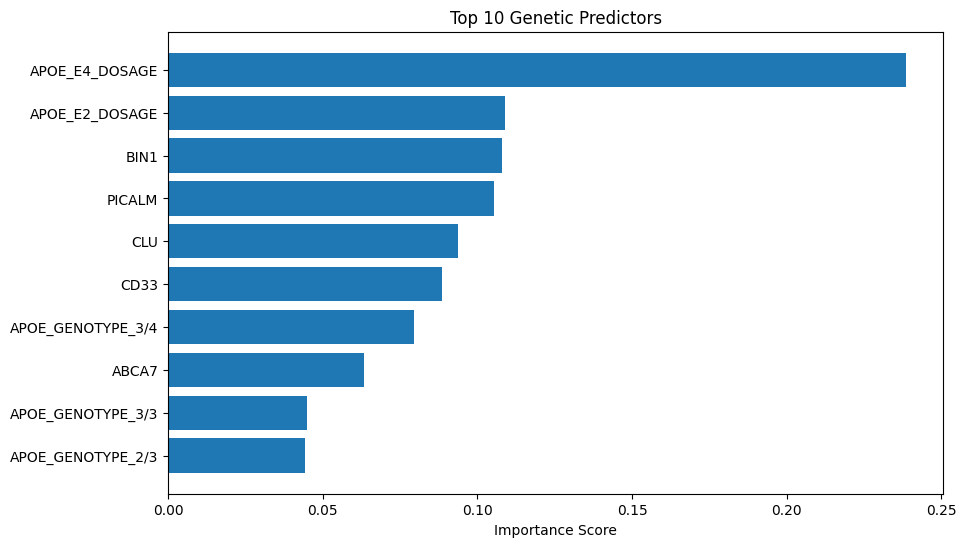

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
importance = model.feature_importances_
feature_names = X.columns

# Create a dataframe for visualization
feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'][:10], feat_importance['Importance'][:10])
plt.xlabel('Importance Score')
plt.title('Top 10 Genetic Predictors')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import numpy as np

# Use a small epsilon to avoid division by zero
epsilon = 1e-10
f1_scores = 2 * (precision * recall) / (precision + recall + epsilon)

# Now find the index of the maximum F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold: 0.5730
Best F1-Score: 0.3929


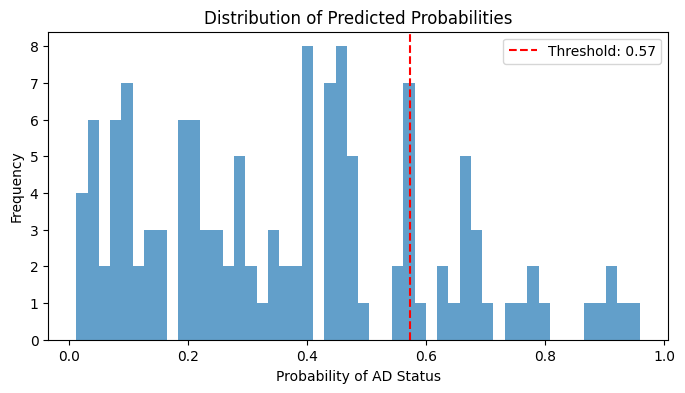

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(y_probs, bins=50, alpha=0.7)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of AD Status')
plt.ylabel('Frequency')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold: {best_threshold:.2f}')
plt.legend()
plt.show()

In [ ]:
# Example: Create an interaction term between APOE and other high-risk genes
df['APOE_x_BIN1'] = df['APOE_E4_DOSAGE'] * df['BIN1']
df['APOE_x_CLU'] = df['APOE_E4_DOSAGE'] * df['CLU']

# Re-run your model pipeline with these new columns

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores instead of binary predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Calculate precision and recall for every possible threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calculate F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that gives the highest F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")

# You can now apply this threshold to your model
# y_pred_optimized = (y_probs >= best_threshold).astype(int)

Optimal Threshold: 0.9590
Best F1-Score: nan


/tmp/ipykernel_948/2630887389.py:11: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


In [ ]:
!pip install optuna
import optuna
from sklearn.metrics import f1_score # Import f1_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0)
    }

    model = xgb.XGBClassifier(**params, eval_metric='logloss')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.0 MB/s eta 0:00:00


In [ ]:
# 1. Run the Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 2. View the best results
print("Number of finished trials: ", len(study.trials))
print("Best trial F1-score: ", study.best_trial.value)
print("Best parameters: ", study.best_params)

# 3. Retrain the model with the optimized parameters
best_params = study.best_params
final_model = xgb.XGBClassifier(**best_params, eval_metric='logloss')
final_model.fit(X_train, y_train)

# 4. Final Evaluation
final_preds = final_model.predict(X_test)
print("\nFinal Optimized Model Report:")
print(classification_report(y_test, final_preds))

[I 2026-07-01 09:25:22,307] A new study created in memory with name: no-name-db07291c-88ff-4741-8292-1853516ef505
[I 2026-07-01 09:25:22,363] Trial 0 finished with value: 0.30434782608695654 and parameters: {'n_estimators': 143, 'learning_rate': 0.14633848240829547, 'max_depth': 5, 'scale_pos_weight': 2.500821139882989}. Best is trial 0 with value: 0.30434782608695654.
[I 2026-07-01 09:25:22,491] Trial 1 finished with value: 0.375 and parameters: {'n_estimators': 258, 'learning_rate': 0.15277966199978524, 'max_depth': 10, 'scale_pos_weight': 3.4716328037127813}. Best is trial 1 with value: 0.375.
[I 2026-07-01 09:25:22,936] Trial 2 finished with value: 0.37142857142857144 and parameters: {'n_estimators': 221, 'learning_rate': 0.07579527329732784, 'max_depth': 10, 'scale_pos_weight': 4.592253931019872}. Best is trial 1 with value: 0.375.
[I 2026-07-01 09:25:23,085] Trial 3 finished with value: 0.25 and parameters: {'n_estimators': 70, 'learning_rate': 0.28749314790508096, 'max_depth': 3

Number of finished trials:  50
Best trial F1-score:  0.4126984126984127
Best parameters:  {'n_estimators': 105, 'learning_rate': 0.1973966645012585, 'max_depth': 7, 'scale_pos_weight': 3.1910401375502944}

Final Optimized Model Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       104
           1       0.35      0.50      0.41        26

    accuracy                           0.72       130
   macro avg       0.61      0.63      0.61       130
weighted avg       0.76      0.72      0.73       130



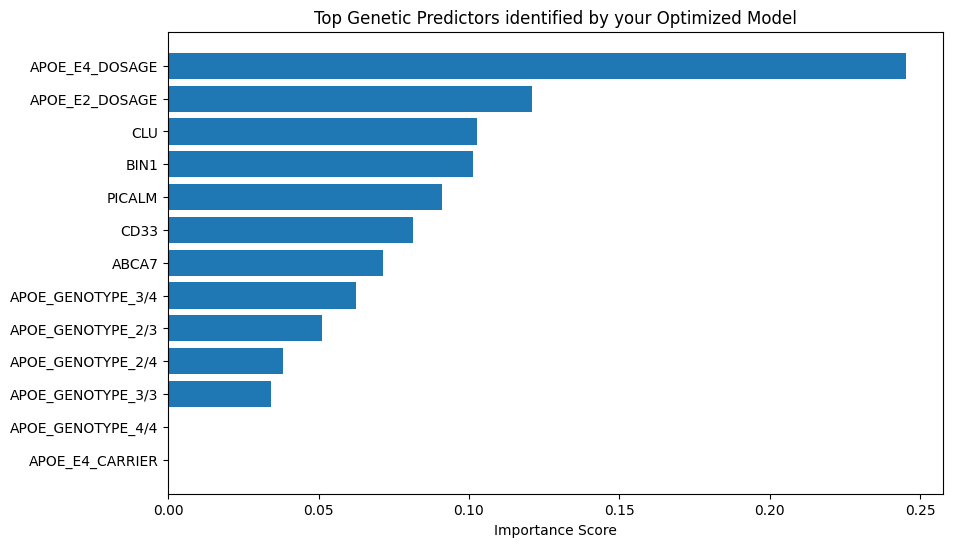

In [ ]:
import matplotlib.pyplot as plt

# Extract importance from the final_model
importance = final_model.feature_importances_
feature_names = X.columns

# Sort features by importance
feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'])
plt.title('Top Genetic Predictors identified by your Optimized Model')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score
from sklearn.impute import SimpleImputer

# 1. Data Prep
df = pd.read_csv('/content/alzheimers_final_ml_dataset_with_trajectory (1).csv')
df.dropna(subset=['AD_STATUS'], inplace=True)

# Define leakage columns
leakage_cols = ['Sample', 'BASELINE_DX', 'BASELINE_DX_ENC', 'DIAGNOSIS_WORST',
                'EARLY_TRAJECTORY', 'EARLY_TRAJECTORY_ENC', 'n_visits', 'AD_STATUS']

X = df.drop(columns=[c for c in leakage_cols if c in df.columns])
y = df['AD_STATUS'].astype(int)

# Handle Missing Values in Categorical Data
# Simple mode imputation for the categorical genotype column
imputer = SimpleImputer(strategy='most_frequent')
X['APOE_GENOTYPE'] = imputer.fit_transform(X[['APOE_GENOTYPE']])[:, 0] # Fix: Extract the 1D array

# One-hot encoding
X = pd.get_dummies(X, columns=['APOE_GENOTYPE'], drop_first=True)

# 2. Stratified Split (The "Golden" Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Dynamic Weight Calculation
# Calculate ratio based strictly on training data
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
weight_ratio = neg_count / pos_count

# 4. Optuna with Cross-Validation
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'scale_pos_weight': weight_ratio # Fixed ratio for consistency
    }

    model = xgb.XGBClassifier(**params, eval_metric='logloss')

    # Use Stratified K-Fold for validation to keep folds balanced
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate F1 score using Cross-Validation
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 5. Final Evaluation on Untouched Test Set
best_model = xgb.XGBClassifier(**study.best_params, eval_metric='logloss')
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("--- Robust Model Performance Report ---")
print(classification_report(y_test, y_pred))

[I 2026-07-01 09:32:25,872] A new study created in memory with name: no-name-a7a31680-9480-4cdd-9c54-2d5bcb2bff85
[I 2026-07-01 09:32:26,196] Trial 0 finished with value: 0.29481559698619597 and parameters: {'n_estimators': 160, 'learning_rate': 0.1150663588483302, 'max_depth': 7}. Best is trial 0 with value: 0.29481559698619597.
[I 2026-07-01 09:32:26,778] Trial 1 finished with value: 0.27756208153233325 and parameters: {'n_estimators': 290, 'learning_rate': 0.12509441159404658, 'max_depth': 8}. Best is trial 0 with value: 0.29481559698619597.
[I 2026-07-01 09:32:27,338] Trial 2 finished with value: 0.28682182590904703 and parameters: {'n_estimators': 205, 'learning_rate': 0.07459598304800784, 'max_depth': 8}. Best is trial 0 with value: 0.29481559698619597.
[I 2026-07-01 09:32:28,306] Trial 3 finished with value: 0.298367816091954 and parameters: {'n_estimators': 113, 'learning_rate': 0.1663046867217398, 'max_depth': 7}. Best is trial 3 with value: 0.298367816091954.
[I 2026-07-01 09

--- Robust Model Performance Report ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       106
           1       0.33      0.25      0.29        24

    accuracy                           0.77       130
   macro avg       0.59      0.57      0.57       130
weighted avg       0.75      0.77      0.76       130



[I 2026-07-01 09:38:35,753] A new study created in memory with name: no-name-fa86b4d3-4444-4b0a-bbfa-02b540958249
[I 2026-07-01 09:38:36,627] Trial 0 finished with value: 0.5175326853460314 and parameters: {'n_estimators': 343, 'learning_rate': 0.010734239507654121, 'max_depth': 4, 'subsample': 0.8762471350308596, 'colsample_bytree': 0.9420696765645897, 'min_child_weight': 6, 'gamma': 0.9309156714911809}. Best is trial 0 with value: 0.5175326853460314.
[I 2026-07-01 09:38:36,974] Trial 1 finished with value: 0.48731521194561134 and parameters: {'n_estimators': 429, 'learning_rate': 0.2947693748530725, 'max_depth': 8, 'subsample': 0.9167299739517757, 'colsample_bytree': 0.8078169722548735, 'min_child_weight': 7, 'gamma': 2.728904036635095}. Best is trial 0 with value: 0.5175326853460314.
[I 2026-07-01 09:38:37,250] Trial 2 finished with value: 0.5097826533698762 and parameters: {'n_estimators': 283, 'learning_rate': 0.1769742171410057, 'max_depth': 8, 'subsample': 0.673550570278049, 'co

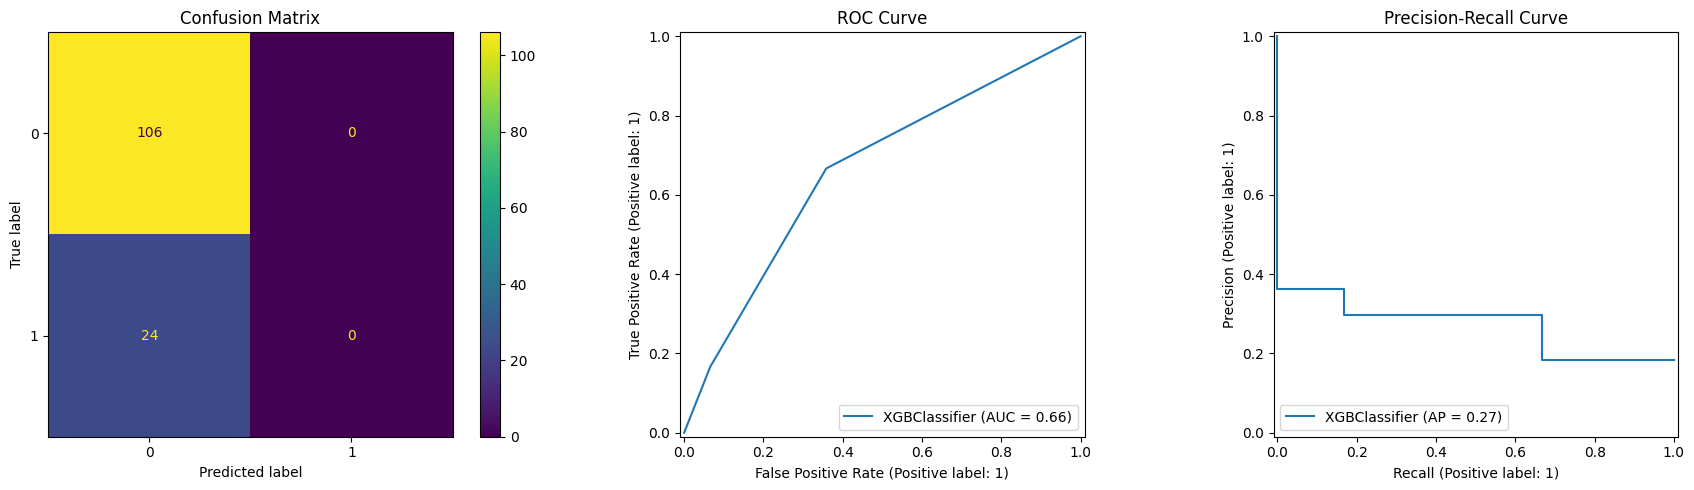

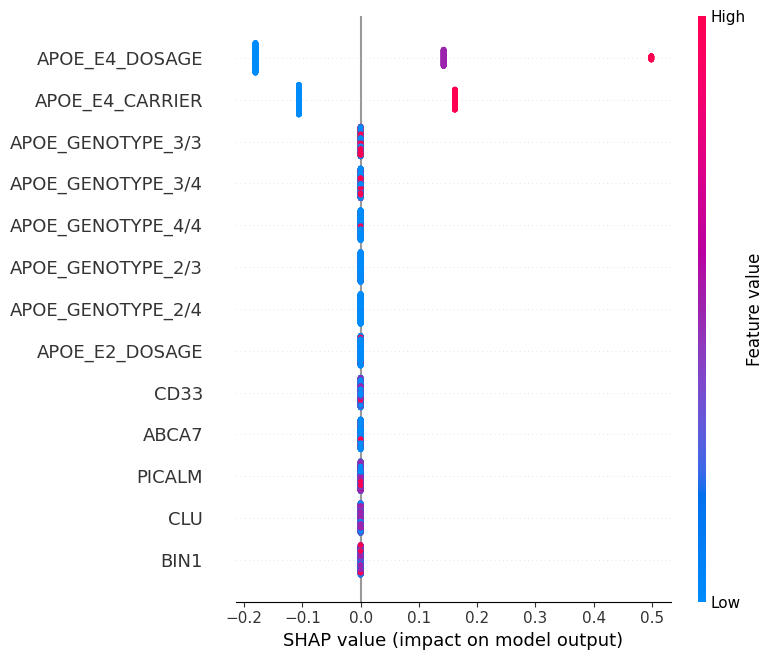

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.impute import SimpleImputer

# 1. Data Prep & Imputation
df = pd.read_csv('/content/alzheimers_final_ml_dataset_with_trajectory (1).csv')
df.dropna(subset=['AD_STATUS'], inplace=True)

leakage_cols = ['Sample', 'BASELINE_DX', 'BASELINE_DX_ENC', 'DIAGNOSIS_WORST',
                'EARLY_TRAJECTORY', 'EARLY_TRAJECTORY_ENC', 'n_visits', 'AD_STATUS']
X = df.drop(columns=[c for c in leakage_cols if c in df.columns])
y = df['AD_STATUS'].astype(int)

# Numeric Imputation (Median for robustness against outliers)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical Imputation (Mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
X['APOE_GENOTYPE'] = cat_imputer.fit_transform(X[['APOE_GENOTYPE']])[:, 0] # Fix: Extract the 1D array
X = pd.get_dummies(X, columns=['APOE_GENOTYPE'], drop_first=True)

# 2. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Dynamic Weight
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Optuna with Expanded Space
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": weight_ratio
    }
    model = xgb.XGBClassifier(**params, eval_metric='logloss')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Optimizing for F1-Macro
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 4. Train Final Model
final_model = xgb.XGBClassifier(**study.best_params, eval_metric='logloss')
final_model.fit(X_train, y_train)

# 5. Advanced Evaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

# SHAP Interpretability
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

[I 2026-07-01 09:41:40,090] A new study created in memory with name: no-name-cf613e83-8db8-4cef-8d08-5ee7489d0537


scale_pos_weight = 4.463157894736842


[I 2026-07-01 09:41:41,255] Trial 0 finished with value: 0.5425990036658844 and parameters: {'n_estimators': 380, 'learning_rate': 0.011032224150229442, 'max_depth': 5, 'subsample': 0.7408382197500889, 'colsample_bytree': 0.6799337843250713, 'min_child_weight': 7, 'gamma': 2.018045334932772}. Best is trial 0 with value: 0.5425990036658844.
[I 2026-07-01 09:41:43,868] Trial 1 finished with value: 0.5074510621035986 and parameters: {'n_estimators': 409, 'learning_rate': 0.05304015613835527, 'max_depth': 8, 'subsample': 0.7841032063327265, 'colsample_bytree': 0.7210366967591194, 'min_child_weight': 1, 'gamma': 1.6424309361731009}. Best is trial 0 with value: 0.5425990036658844.
[I 2026-07-01 09:41:44,826] Trial 2 finished with value: 0.5342146588368917 and parameters: {'n_estimators': 309, 'learning_rate': 0.21098657018164663, 'max_depth': 3, 'subsample': 0.6948456349416876, 'colsample_bytree': 0.7504621862043109, 'min_child_weight': 7, 'gamma': 3.304873684537305}. Best is trial 0 with va


Best Parameters
{'n_estimators': 159, 'learning_rate': 0.19421715774692455, 'max_depth': 7, 'subsample': 0.9998058935802615, 'colsample_bytree': 0.9960268256485143, 'min_child_weight': 6, 'gamma': 4.5980459606745265}

Best Threshold = 0.469

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.61      0.72       106
           1       0.27      0.62      0.38        24

    accuracy                           0.62       130
   macro avg       0.57      0.62      0.55       130
weighted avg       0.77      0.62      0.66       130



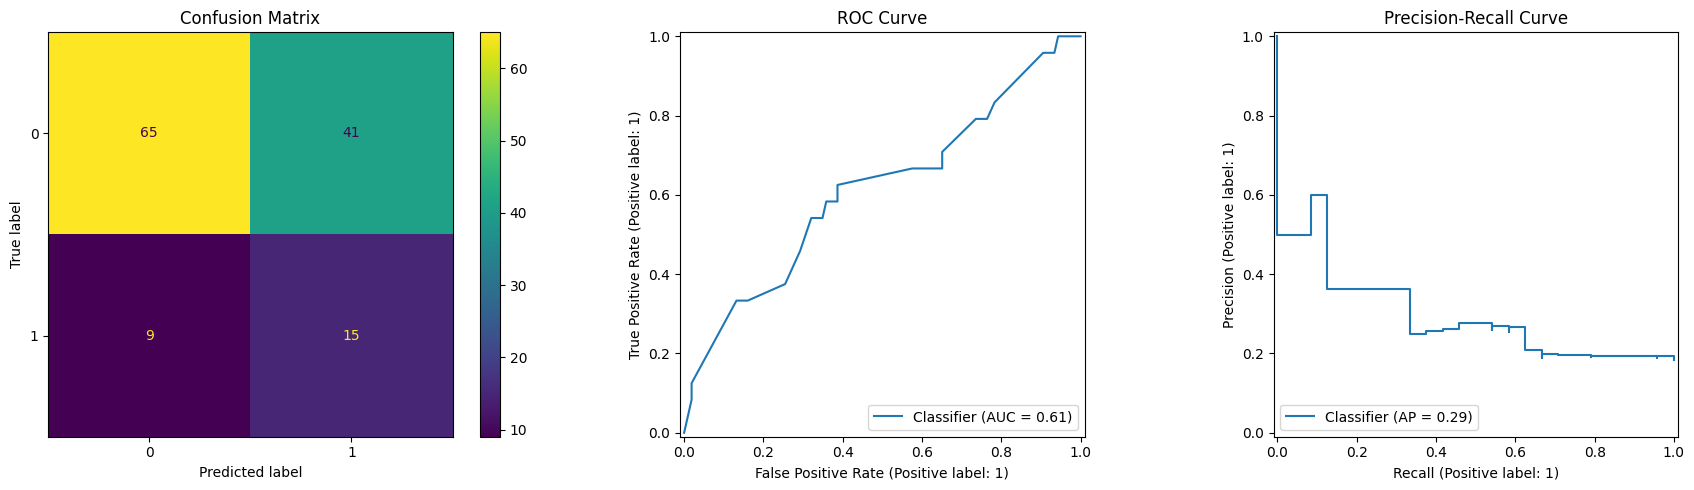

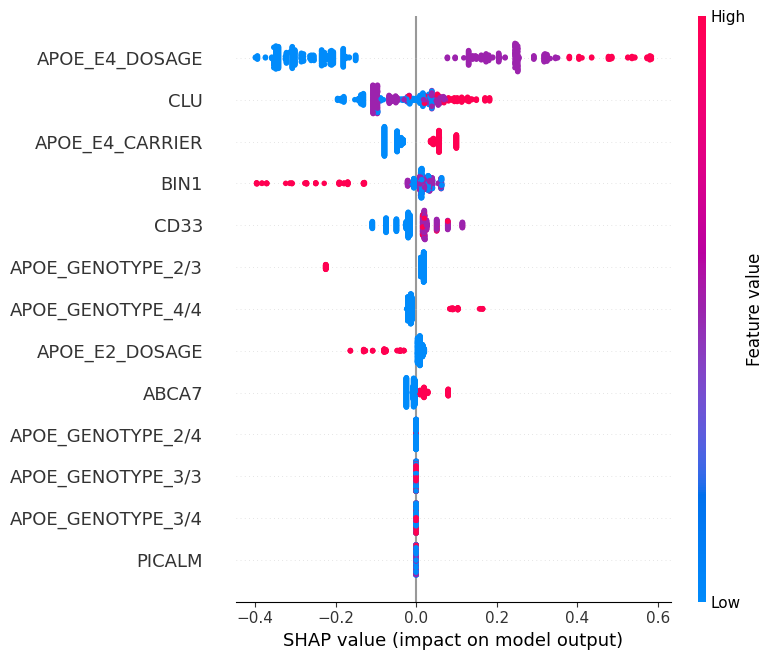


Top Features

              Feature  Importance
5      APOE_E4_DOSAGE    0.259019
12  APOE_GENOTYPE_4/4    0.127718
6      APOE_E2_DOSAGE    0.103689
3               ABCA7    0.101637
1                 CLU    0.093285
4                CD33    0.083669
8   APOE_GENOTYPE_2/3    0.081810
0                BIN1    0.080648
7     APOE_E4_CARRIER    0.068525
2              PICALM    0.000000
9   APOE_GENOTYPE_2/4    0.000000
10  APOE_GENOTYPE_3/3    0.000000
11  APOE_GENOTYPE_3/4    0.000000


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    f1_score
)

from sklearn.impute import SimpleImputer

# =====================================================
# 1. Load Dataset
# =====================================================

df = pd.read_csv("/content/alzheimers_final_ml_dataset_with_trajectory (1).csv")
df.dropna(subset=["AD_STATUS"], inplace=True)

# =====================================================
# 2. Remove Leakage
# =====================================================

leakage_cols = [
    "Sample",
    "BASELINE_DX",
    "BASELINE_DX_ENC",
    "DIAGNOSIS_WORST",
    "EARLY_TRAJECTORY",
    "EARLY_TRAJECTORY_ENC",
    "n_visits",
    "AD_STATUS"
]

X = df.drop(columns=[c for c in leakage_cols if c in df.columns])
y = df["AD_STATUS"].astype(int)

# =====================================================
# 3. Missing Value Imputation
# =====================================================

num_cols = X.select_dtypes(include=["int64", "float64"]).columns

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X["APOE_GENOTYPE"] = cat_imputer.fit_transform(
    X[["APOE_GENOTYPE"]]
).ravel()

# =====================================================
# 4. One-Hot Encoding
# =====================================================

X = pd.get_dummies(
    X,
    columns=["APOE_GENOTYPE"],
    drop_first=True
)

# =====================================================
# 5. Stratified Train/Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# 6. Calculate Class Weight
# =====================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight =", scale_pos_weight)

# =====================================================
# 7. Optuna Optimization
# =====================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators",100,500),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            8
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "scale_pos_weight": scale_pos_weight,

        "random_state":42,

        "eval_metric":"logloss"
    }

    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nBest Parameters")
print(study.best_params)

# =====================================================
# 8. Train Final Model
# =====================================================

best_params = study.best_params.copy()

# IMPORTANT FIX
best_params["scale_pos_weight"] = scale_pos_weight
best_params["random_state"] = 42
best_params["eval_metric"] = "logloss"

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X_train, y_train)

# =====================================================
# 9. Threshold Optimization
# =====================================================

probabilities = final_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probabilities
)

f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("\nBest Threshold =", round(best_threshold,3))

# =====================================================
# 10. Final Predictions
# =====================================================

y_pred = (probabilities >= best_threshold).astype(int)

# =====================================================
# 11. Classification Report
# =====================================================

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred
))

# =====================================================
# 12. Confusion Matrix
# =====================================================

fig, axes = plt.subplots(1,3,figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")

# =====================================================
# 13. ROC Curve
# =====================================================

RocCurveDisplay.from_predictions(
    y_test,
    probabilities,
    ax=axes[1]
)

axes[1].set_title("ROC Curve")

# =====================================================
# 14. Precision Recall Curve
# =====================================================

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilities,
    ax=axes[2]
)

axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

# =====================================================
# 15. SHAP
# =====================================================

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(
    shap_values,
    X_train,
    max_display=15
)

# =====================================================
# 16. Feature Importance
# =====================================================

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features\n")
print(importance.head(20))

[I 2026-07-01 09:45:19,170] A new study created in memory with name: no-name-a38c1918-b94a-41ca-bb70-060aa646be52


scale_pos_weight = 4.469879518072289


[I 2026-07-01 09:45:24,095] Trial 0 finished with value: 0.5387898356207136 and parameters: {'n_estimators': 200, 'learning_rate': 0.13368167908451703, 'max_depth': 7, 'subsample': 0.7136541556442398, 'colsample_bytree': 0.8882690339327685, 'min_child_weight': 10, 'gamma': 0.43095962087703443}. Best is trial 0 with value: 0.5387898356207136.
[I 2026-07-01 09:45:24,531] Trial 1 finished with value: 0.5583460112001026 and parameters: {'n_estimators': 387, 'learning_rate': 0.03758403651135944, 'max_depth': 3, 'subsample': 0.7373391217034566, 'colsample_bytree': 0.8516376443548307, 'min_child_weight': 10, 'gamma': 3.6599062114270127}. Best is trial 1 with value: 0.5583460112001026.
[I 2026-07-01 09:45:24,968] Trial 2 finished with value: 0.5576797283263852 and parameters: {'n_estimators': 322, 'learning_rate': 0.012918999404138416, 'max_depth': 4, 'subsample': 0.8595404461704654, 'colsample_bytree': 0.7812105779063669, 'min_child_weight': 5, 'gamma': 2.6569280820916275}. Best is trial 1 wi

{'n_estimators': 295, 'learning_rate': 0.02031089250272551, 'max_depth': 5, 'subsample': 0.7786770203671693, 'colsample_bytree': 0.9380936018092486, 'min_child_weight': 7, 'gamma': 3.911932342697211}
Best Threshold = 0.24437416
              precision    recall  f1-score   support

           0       0.83      0.06      0.12        80
           1       0.18      0.94      0.31        18

    accuracy                           0.22        98
   macro avg       0.51      0.50      0.21        98
weighted avg       0.71      0.22      0.15        98



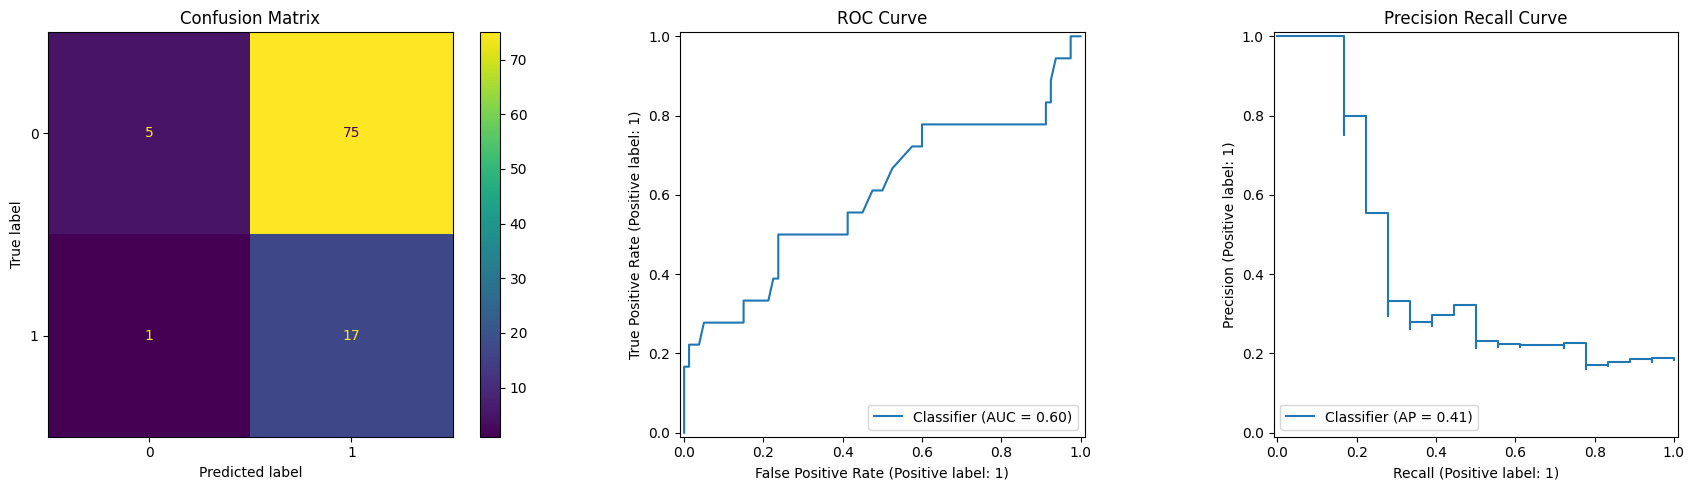

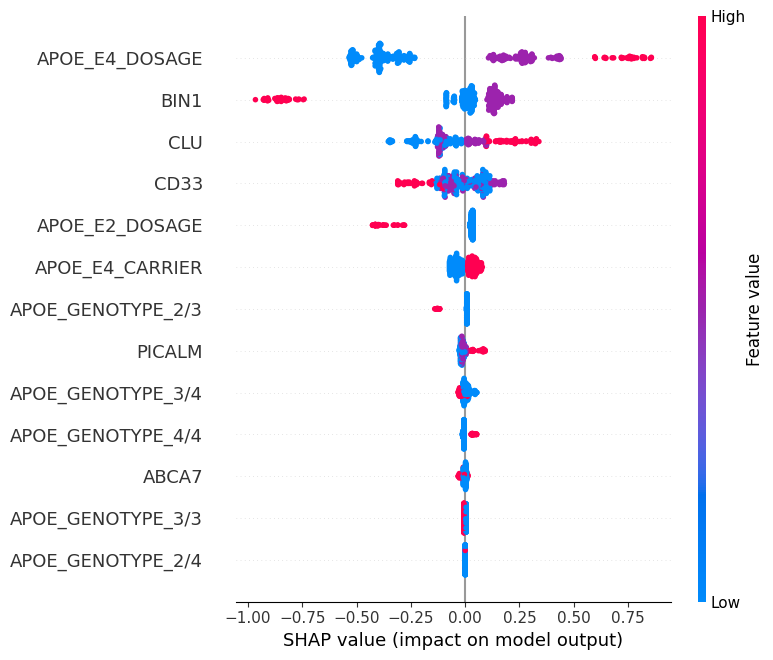

              Feature  Importance
7     APOE_E4_CARRIER    0.164350
5      APOE_E4_DOSAGE    0.106544
12  APOE_GENOTYPE_4/4    0.096547
8   APOE_GENOTYPE_2/3    0.094287
0                BIN1    0.075975
11  APOE_GENOTYPE_3/4    0.071352
4                CD33    0.071047
1                 CLU    0.069623
10  APOE_GENOTYPE_3/3    0.068278
6      APOE_E2_DOSAGE    0.066943
3               ABCA7    0.060566
2              PICALM    0.054487
9   APOE_GENOTYPE_2/4    0.000000


In [ ]:
# =====================================================
# 5. Train / Validation / Test Split
# =====================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# =====================================================
# 6. Class Weight
# =====================================================

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight =", scale_pos_weight)

# =====================================================
# 7. Optuna
# =====================================================

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators",100,500),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.30,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            8
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "scale_pos_weight": scale_pos_weight,

        "tree_method":"hist",

        "eval_metric":"aucpr",

        "random_state":42,

        "n_jobs":-1,

        "use_label_encoder":False

    }

    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(study.best_params)

# =====================================================
# 8. Final Model
# =====================================================

best_params = study.best_params.copy()

best_params["scale_pos_weight"] = scale_pos_weight
best_params["tree_method"] = "hist"
best_params["eval_metric"] = "aucpr"
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["use_label_encoder"] = False

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid,y_valid)],
    verbose=False
)

# =====================================================
# 9. Threshold Optimization
# =====================================================

valid_prob = final_model.predict_proba(X_valid)[:,1]

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    valid_prob
)

f1_scores = (
    2*precision*recall/(precision+recall+1e-10)
)

best_index = np.argmax(f1_scores[:-1])

best_threshold = thresholds[best_index]

print("Best Threshold =",best_threshold)

# =====================================================
# 10. Test Prediction
# =====================================================

test_prob = final_model.predict_proba(X_test)[:,1]

y_pred = (test_prob >= best_threshold).astype(int)

# =====================================================
# 11. Classification Report
# =====================================================

print(classification_report(y_test,y_pred))

# =====================================================
# 12. Confusion Matrix
# =====================================================

fig,axes = plt.subplots(1,3,figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[1]
)

axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[2]
)

axes[2].set_title("Precision Recall Curve")

plt.tight_layout()
plt.show()

# =====================================================
# 13. SHAP
# =====================================================

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(
    shap_values,
    X_train,
    max_display=15
)

# =====================================================
# 14. Feature Importance
# =====================================================

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":final_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

[I 2026-07-01 09:55:47,624] A new study created in memory with name: no-name-df01be18-a88c-4cad-8ed9-f2c387cd564b


scale_pos_weight = 4.455445544554456


[I 2026-07-01 09:55:48,042] Trial 0 finished with value: 0.2393189328516174 and parameters: {'n_estimators': 467, 'learning_rate': 0.05125984647618621, 'max_depth': 6, 'subsample': 0.9745087360867756, 'colsample_bytree': 0.8209465409275671, 'min_child_weight': 1, 'gamma': 2.4864524913145836}. Best is trial 0 with value: 0.2393189328516174.
[I 2026-07-01 09:55:48,455] Trial 1 finished with value: 0.24070056241946042 and parameters: {'n_estimators': 415, 'learning_rate': 0.01844207150649021, 'max_depth': 8, 'subsample': 0.8440142851575755, 'colsample_bytree': 0.8200952206269212, 'min_child_weight': 3, 'gamma': 2.264913654838065}. Best is trial 1 with value: 0.24070056241946042.
[I 2026-07-01 09:55:48,616] Trial 2 finished with value: 0.2570078742873533 and parameters: {'n_estimators': 137, 'learning_rate': 0.04032358779276589, 'max_depth': 7, 'subsample': 0.7579864780973381, 'colsample_bytree': 0.7177051953517843, 'min_child_weight': 9, 'gamma': 4.816401590119372}. Best is trial 2 with v

Best params: {'n_estimators': 440, 'learning_rate': 0.07575490143407952, 'max_depth': 6, 'subsample': 0.832124577434154, 'colsample_bytree': 0.8202962218868193, 'min_child_weight': 10, 'gamma': 4.290480791581735}
Best CV PR-AUC: 0.26412563431177416
Threshold chosen from CV out-of-fold PR curve (F1-optimal): 0.39191815
              precision    recall  f1-score   support

           0       0.84      0.39      0.53        80
           1       0.20      0.67      0.30        18

    accuracy                           0.44        98
   macro avg       0.52      0.53      0.42        98
weighted avg       0.72      0.44      0.49        98

ROC-AUC: 0.6284722222222222
PR-AUC : 0.4008080413513252


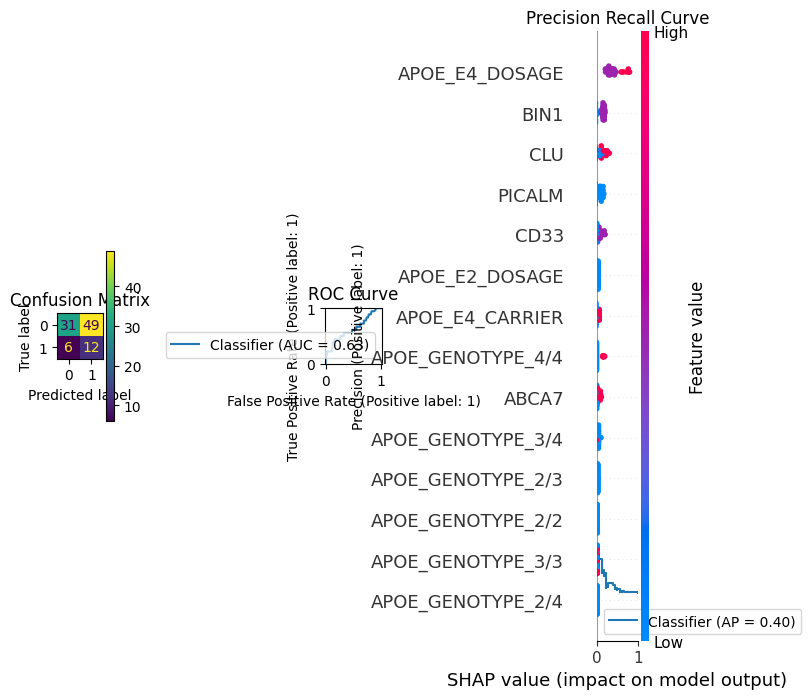

In [ ]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# 1. Load and prep data
# ---------------------------------------------------------------------------
df = pd.read_csv("/content/alzheimers_final_ml_dataset_with_trajectory (1).csv")
df = df.dropna(subset=["AD_STATUS"]).copy()

genotype_dummies = pd.get_dummies(df["APOE_GENOTYPE"], prefix="APOE_GENOTYPE")

feature_cols = ["BIN1", "CLU", "PICALM", "ABCA7", "CD33",
                 "APOE_E4_DOSAGE", "APOE_E2_DOSAGE", "APOE_E4_CARRIER"]

X = pd.concat([df[feature_cols], genotype_dummies], axis=1)
y = df["AD_STATUS"].astype(int)

# split off the test set FIRST and never touch it until final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", scale_pos_weight)

# ---------------------------------------------------------------------------
# 2. Optuna hyperparameter search (unchanged approach, CV on train only)
# ---------------------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "aucpr",     # optimize for the imbalanced metric directly
        "random_state": RANDOM_STATE,
    }
    model = xgb.XGBClassifier(**params)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv,
                                   method="predict_proba")[:, 1]
    return average_precision_score(y_train, oof_proba)   # PR-AUC, not ROC-AUC

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = study.best_params
print("Best params:", best_params)
print("Best CV PR-AUC:", study.best_value)

# ---------------------------------------------------------------------------
# 3. Threshold selection via cross-validated out-of-fold predictions
#    (never on the test set — that was the bug)
# ---------------------------------------------------------------------------
final_model_params = dict(best_params)
final_model_params["scale_pos_weight"] = scale_pos_weight
final_model_params["random_state"] = RANDOM_STATE

model = xgb.XGBClassifier(**final_model_params)
oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])   # last point has no matching threshold
best_threshold = thresholds[best_idx]
print("Threshold chosen from CV out-of-fold PR curve (F1-optimal):", best_threshold)

# ---------------------------------------------------------------------------
# 4. Fit final model on full training set, evaluate ONCE on held-out test set
# ---------------------------------------------------------------------------
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print(classification_report(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("PR-AUC :", average_precision_score(y_test, test_proba))

# ---------------------------------------------------------------------------
# 5. Plots
# ---------------------------------------------------------------------------

# Create the output directory if it doesn't exist
os.makedirs("/mnt/user-data/outputs", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred)).plot(ax=axes[0])
axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[2])
axes[2].set_title("Precision Recall Curve")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/eval_plots.png", dpi=150)

# ---------------------------------------------------------------------------
# 6. SHAP
# ---------------------------------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/shap_summary.png", dpi=150)

In [ ]:
import pandas as pd

df_new_data = pd.read_csv('/content/alzheimers_dataset_with_clinical.csv')
print('Successfully loaded the new dataset:')
display(df_new_data.head())

Successfully loaded the new dataset:


,Sample,BIN1,CLU,PICALM,ABCA7,CD33,APOE_GENOTYPE,APOE_E4_DOSAGE,APOE_E2_DOSAGE,APOE_E4_CARRIER,...,CDR_SB,LIMMTOTAL,LDELTOTAL,TRAASCOR,TRABSCOR,CATANIMSC,AVTOT6,AVDELTOT,AMYLOID_STATUS,CENTILOIDS
0,036_S_6231,0.0,0.0,1.0,0.0,0.0,3/4,1.0,0.0,1.0,...,2.0,2.0,2.0,115.0,NaN,9.0,0.0,3.0,1.0,90.0
1,006_S_6277,0.0,1.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,...,0.0,14.0,14.0,21.0,46.0,22.0,7.0,13.0,0.0,4.0
2,129_S_6146,1.0,2.0,0.0,1.0,1.0,3/3,0.0,0.0,0.0,...,0.0,14.0,13.0,28.0,37.0,26.0,10.0,14.0,0.0,-11.0
3,033_S_6352,1.0,1.0,1.0,0.0,0.0,3/4,1.0,0.0,1.0,...,0.0,14.0,15.0,25.0,48.0,21.0,8.0,11.0,0.0,1.0
4,027_S_6183,1.0,0.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,...,0.0,14.0,12.0,18.0,35.0,26.0,13.0,15.0,0.0,15.0


In [ ]:
# -----------------------------
# Select only genetic biomarkers
# -----------------------------

genetic_features = [
    'BIN1',
    'CLU',
    'PICALM',
    'ABCA7',
    'CD33',
    'APOE_GENOTYPE',
    'APOE_E2_DOSAGE',
    'APOE_E4_DOSAGE',
    'APOE_E4_CARRIER'
]

# Target
target = 'AD_STATUS'

df = df_new_data[genetic_features + [target]].copy()

print(df.shape)
display(df.head())

(655, 10)


,BIN1,CLU,PICALM,ABCA7,CD33,APOE_GENOTYPE,APOE_E2_DOSAGE,APOE_E4_DOSAGE,APOE_E4_CARRIER,AD_STATUS
0,0.0,0.0,1.0,0.0,0.0,3/4,0.0,1.0,1.0,1.0
1,0.0,1.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,0.0
2,1.0,2.0,0.0,1.0,1.0,3/3,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,0.0,0.0,3/4,0.0,1.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,3/3,0.0,0.0,0.0,0.0


In [ ]:
df = pd.get_dummies(
    df,
    columns=['APOE_GENOTYPE'],
    prefix='APOE_GENOTYPE'
)

display(df.head())

,BIN1,CLU,PICALM,ABCA7,CD33,APOE_E2_DOSAGE,APOE_E4_DOSAGE,APOE_E4_CARRIER,AD_STATUS,APOE_GENOTYPE_2/2,APOE_GENOTYPE_2/3,APOE_GENOTYPE_2/4,APOE_GENOTYPE_3/3,APOE_GENOTYPE_3/4,APOE_GENOTYPE_4/4
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,False,False,False,False,True,False
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False,True,False,False
2,1.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False,True,False,False
3,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,False,False,False,False,True,False
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False,True,False,False


In [ ]:
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

print("Dataset after removing missing values:")
print(df.shape)

BIN1                 3
CLU                  0
PICALM               0
ABCA7                0
CD33                 0
APOE_E2_DOSAGE       5
APOE_E4_DOSAGE       5
APOE_E4_CARRIER      5
AD_STATUS            6
APOE_GENOTYPE_2/2    0
APOE_GENOTYPE_2/3    0
APOE_GENOTYPE_2/4    0
APOE_GENOTYPE_3/3    0
APOE_GENOTYPE_3/4    0
APOE_GENOTYPE_4/4    0
dtype: int64
Dataset after removing missing values:
(646, 15)


In [ ]:
X = df.drop('AD_STATUS', axis=1)
y = df['AD_STATUS']

print(X.shape)
print(y.value_counts())

(646, 14)
AD_STATUS
0.0    528
1.0    118
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(516, 14)
(130, 14)


In [ ]:
print(y_train.value_counts(normalize=True))

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("scale_pos_weight =", scale_pos_weight)

AD_STATUS
0.0    0.817829
1.0    0.182171
Name: proportion, dtype: float64
scale_pos_weight = 4.48936170212766


In [ ]:
genetic_features = [
    'BIN1',
    'CLU',
    'PICALM',
    'ABCA7',
    'CD33',
    'APOE_E2_DOSAGE',
    'APOE_E4_DOSAGE',
    'APOE_E4_CARRIER',
    'APOE_GENOTYPE_2/3',
    'APOE_GENOTYPE_2/4',
    'APOE_GENOTYPE_3/3',
    'APOE_GENOTYPE_3/4',
    'APOE_GENOTYPE_4/4'
]

X = df[genetic_features]
y = df['AD_STATUS']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(516, 13)
(130, 13)


In [ ]:
from collections import Counter

counter = Counter(y_train)

scale_pos_weight = counter[0] / counter[1]

print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 4.48936170212766


In [ ]:
!pip install optuna
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators",150,500),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
        "max_depth": trial.suggest_int("max_depth",3,8),
        "subsample": trial.suggest_float("subsample",0.7,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.7,1.0),
        "min_child_weight": trial.suggest_int("min_child_weight",1,10),
        "gamma": trial.suggest_float("gamma",0,5),
        "scale_pos_weight": scale_pos_weight,
        "random_state":42,
        "eval_metric":"logloss"
    }

    scores=[]

    for train_idx,val_idx in cv.split(X_train,y_train):

        X_tr=X_train.iloc[train_idx]
        X_val=X_train.iloc[val_idx]

        y_tr=y_train.iloc[train_idx]
        y_val=y_train.iloc[val_idx]

        model=XGBClassifier(**params)

        model.fit(X_tr,y_tr)

        probs=model.predict_proba(X_val)[:,1]

        score=average_precision_score(y_val,probs)

        scores.append(score)

    return np.mean(scores)

study=optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=50)

print(study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.1 MB/s eta 0:00:00


[I 2026-07-01 10:27:21,780] A new study created in memory with name: no-name-2c8c4c26-0226-4ffc-9442-3c75dd02a348
[I 2026-07-01 10:27:23,511] Trial 0 finished with value: 0.34014488679462523 and parameters: {'n_estimators': 398, 'learning_rate': 0.016510545018432896, 'max_depth': 6, 'subsample': 0.9864925632343928, 'colsample_bytree': 0.8417470751137857, 'min_child_weight': 10, 'gamma': 4.399333295407082}. Best is trial 0 with value: 0.34014488679462523.
[I 2026-07-01 10:27:24,004] Trial 1 finished with value: 0.36128060552610275 and parameters: {'n_estimators': 492, 'learning_rate': 0.03831396109213679, 'max_depth': 6, 'subsample': 0.818444373315847, 'colsample_bytree': 0.7703435897259162, 'min_child_weight': 8, 'gamma': 0.6549236652068174}. Best is trial 1 with value: 0.36128060552610275.
[I 2026-07-01 10:27:24,339] Trial 2 finished with value: 0.351278340368321 and parameters: {'n_estimators': 420, 'learning_rate': 0.01867054988658041, 'max_depth': 8, 'subsample': 0.9302157089156688

{'n_estimators': 221, 'learning_rate': 0.05125988234952303, 'max_depth': 6, 'subsample': 0.8066871028329392, 'colsample_bytree': 0.7041598500359236, 'min_child_weight': 10, 'gamma': 2.607489018567903}


In [ ]:
best_params = study.best_params

model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7041598500359236, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.607489018567903, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05125988234952303,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=221, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, f1_score
from sklearn.model_selection import cross_val_predict
import numpy as np

# Calculate OOF probabilities from the trained model on the training data
oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

# Calculate F1-scores for each threshold
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)

# Find the threshold that maximizes the F1-score
best_idx = np.argmax(f1_scores[:-1]) # Exclude the last threshold if it's 1.0/0.0
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold (from OOF predictions): {best_threshold:.4f}")

probs = model.predict_proba(X_test)[:, 1]
pred = (probs >= best_threshold).astype(int)

print(classification_report(y_test, pred))

Optimal Threshold (from OOF predictions): 0.5919
              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83       106
         1.0       0.30      0.33      0.31        24

    accuracy                           0.73       130
   macro avg       0.57      0.58      0.57       130
weighted avg       0.74      0.73      0.74       130



In [ ]:
importance = pd.DataFrame({
    'Feature': genetic_features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
7     APOE_E4_CARRIER    0.201325
6      APOE_E4_DOSAGE    0.137745
8   APOE_GENOTYPE_2/3    0.086305
11  APOE_GENOTYPE_3/4    0.079166
4                CD33    0.075756
5      APOE_E2_DOSAGE    0.070036
0                BIN1    0.067884
12  APOE_GENOTYPE_4/4    0.065074
1                 CLU    0.063496
2              PICALM    0.061419
3               ABCA7    0.046523
10  APOE_GENOTYPE_3/3    0.045271
9   APOE_GENOTYPE_2/4    0.000000


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)

print(f"ROC-AUC = {roc_auc:.4f}")

ROC-AUC = 0.5737


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)

print(f"ROC-AUC = {roc_auc:.4f}")

ROC-AUC = 0.5737


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, probs)

print(f"PR-AUC = {pr_auc:.4f}")

PR-AUC = 0.3421


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, pred)

print(f"Balanced Accuracy = {balanced_acc:.4f}")

Balanced Accuracy = 0.5770


In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, pred)

print(f"MCC = {mcc:.4f}")

MCC = 0.1474


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[87 19]
 [16  8]]


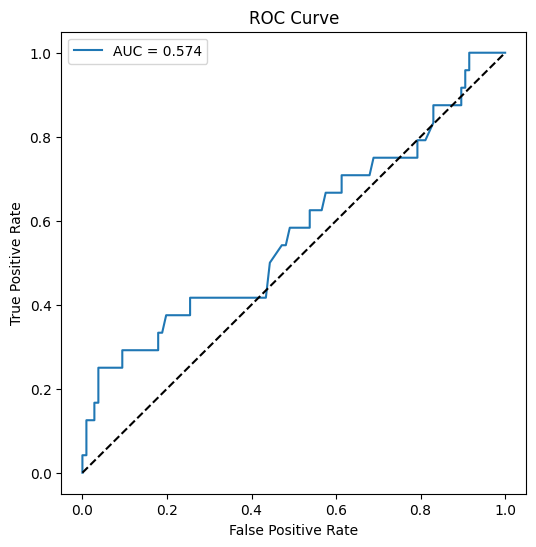

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

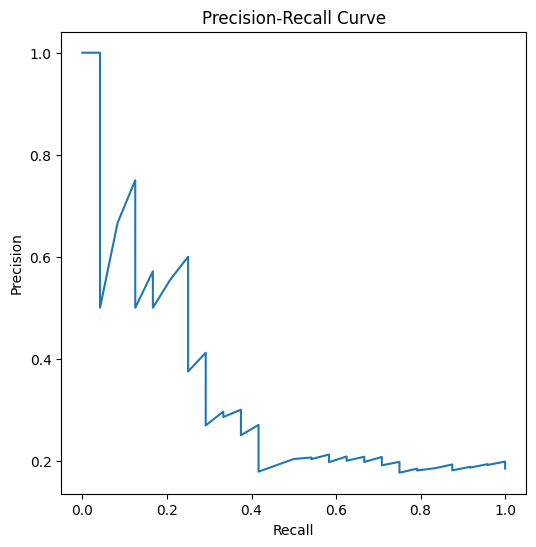

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)